In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
import heapq
import seaborn as sns

from environment.environment import GridWorldMFG_MultiGroup
from trainer.amid_trainer import AMID_Trainer_MultiGroup
from solver.solver import PMFG_OMD_Solver_MultiGroup, solve_multigroup
from visualization.visualizationh import plot_heatmap, compute_exploitability_multigroup, plot_losses

In [3]:
import yaml
import os
from pathlib import Path

def load_config(config_path="config.yaml"):
    """Load configuration from YAML file."""
    # Get the directory where the notebook is located
    notebook_dir = Path(os.getcwd())
    config_file = notebook_dir / config_path
    
    with open(config_file, 'r') as f:
        config = yaml.safe_load(f)
    return config

def create_multigroup_from_config(config):
    """Create environment, solvers, and trainer from config."""
    device = config.get("device", "cuda" if torch.cuda.is_available() else "cpu")
    print(f"Device: {device}")
    
    # Extract grid config
    grid_cfg = config["grid"]
    rows, cols = grid_cfg["rows"], grid_cfg["cols"]
    
    # Convert groups to correct format (convert lists to tuples for coordinates)
    groups = []
    for g in config["groups"]:
        groups.append({
            "source": tuple(g["source"]),
            "sink": tuple(g["sink"]),
            "mass": g["mass"]
        })
    
    # Create environment
    env = GridWorldMFG_MultiGroup(
        rows=rows, cols=cols,
        groups=groups,
        obstacles=grid_cfg.get("obstacles", []),
        device=device
    )
    
    # Create solvers
    solver_cfg = config["solver"]
    solvers = [
        PMFG_OMD_Solver_MultiGroup(
            env, group_idx=k,
            eta=solver_cfg["eta"],
            tau=solver_cfg["tau"],
            T=solver_cfg["T"],
            alpha=solver_cfg["alpha"],
            H=solver_cfg["H"]
        )
        for k in range(env.K)
    ]
    
    # Create trainer
    trainer_cfg = config["trainer"]
    trainer = AMID_Trainer_MultiGroup(env, solvers, leader_lr=trainer_cfg["leader_lr"])
    
    return env, solvers, trainer, config


In [4]:
# Source - https://stackoverflow.com/a/52671057
# Posted by MBT
# Retrieved 2026-05-28, License - CC BY-SA 4.0

def get_lr(optimizer):
    for param_group in optimizer.param_groups:
        return param_group['lr']

In [ ]:
# ─────────────────────────────────────────────────────────────
# 8.  MAIN  — Multi-group from YAML config
# ─────────────────────────────────────────────────────────────

def run_amid_multigroup(config_path="config.yaml"):
    """
    Run AMID training using configuration from YAML file.
    
    Args:
        config_path: Path to YAML config file (relative to notebook directory)
    """
    # Load configuration
    config = load_config(config_path)
    
    # Create environment, solvers, and trainer from config
    env, solvers, trainer, cfg = create_multigroup_from_config(config)

    a = get_lr(trainer.optimizer)
    print(a)

    # Extract parameters
    num_epochs = cfg["trainer"]["num_epochs"]
    
    # Training loop
    losses = []
    print("\nEpoch | Loss")
    print("-" * 25)

    for epoch in range(num_epochs):
        loss = trainer.train_step()
        losses.append(loss)
        if epoch % 1 == 0:
            print(f"{epoch:5d} | {loss:.6f}")

    print("\nTraining completed.")

    # ── Final evaluation ─────────────────────────────────────
    print("\n--- Final Evaluation ---")
    with torch.no_grad():
        inp    = trainer._prepare_input()
        theta1 = trainer.leader_nets(inp)
        theta_list  = [trainer.base_thetas[k] + theta1 for k in range(env.K)]
        print("theta_list", [t.shape for t in theta_list])
        policies, flows, L_total = solve_multigroup(solvers, theta_list)

    exp = compute_exploitability_multigroup(
        solvers, policies, flows, theta_list
    )
    for k, v in exp.items():
        print(f"  Group {k} exploitability: {v:.6f}")

    plot_losses({"Total leader loss": losses})

    return L_total, losses, theta1, env.obstacles
    

if __name__ == "__main__":
    print("Running AMID Multi-Group Example...")

Running AMID Multi-Group Example...


Device: cpu
0.02

Epoch | Loss
-------------------------
theta_leader torch.Size([1, 3, 5])
    0 | 1.971161
theta_leader torch.Size([1, 3, 5])
    1 | 1.986035
theta_leader torch.Size([1, 3, 5])
    2 | 1.962261
theta_leader torch.Size([1, 3, 5])
    3 | 1.850839
theta_leader torch.Size([1, 3, 5])
    4 | 1.802519
theta_leader torch.Size([1, 3, 5])
    5 | 1.786797
theta_leader torch.Size([1, 3, 5])
    6 | 1.639996
theta_leader torch.Size([1, 3, 5])
    7 | 1.638908
theta_leader torch.Size([1, 3, 5])
    8 | 1.686191
theta_leader torch.Size([1, 3, 5])
    9 | 1.654009
theta_leader torch.Size([1, 3, 5])
   10 | 1.621484
theta_leader torch.Size([1, 3, 5])
   11 | 1.627400
theta_leader torch.Size([1, 3, 5])
   12 | 1.644815
theta_leader torch.Size([1, 3, 5])
   13 | 1.643612
theta_leader torch.Size([1, 3, 5])
   14 | 1.631216
theta_leader torch.Size([1, 3, 5])
   15 | 1.623598
theta_leader torch.Size([1, 3, 5])
   16 | 1.624124
theta_leader torch.Size([1, 3, 5])
   17 | 1.628744
theta_l

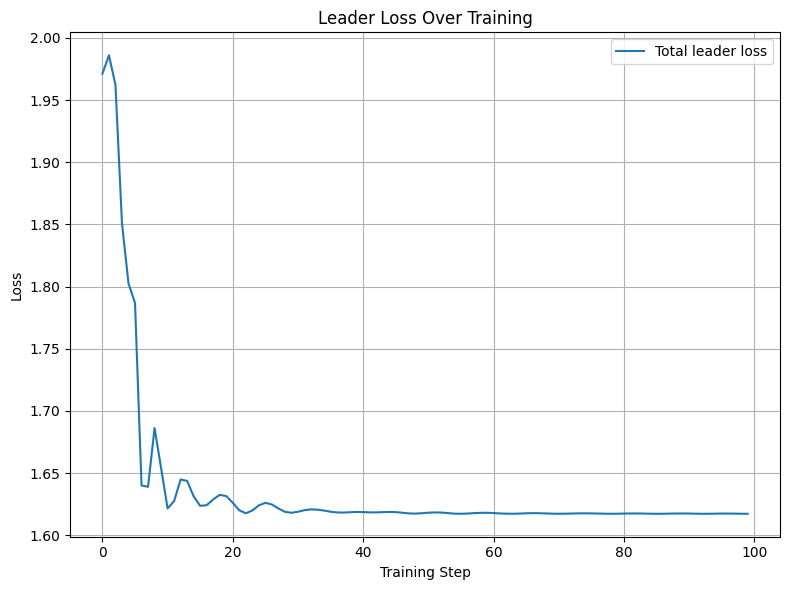

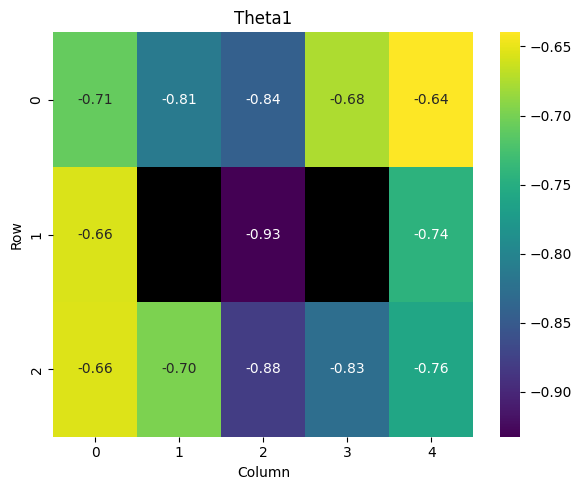

In [12]:
final_flow, losses, theta_leader, obstacles = run_amid_multigroup(config_path="config_braess.yaml")

plot_heatmap(theta_leader[0].cpu().detach().numpy(), mask = obstacles.cpu().detach().numpy(), title="Theta1", xlabel="Column", ylabel="Row")

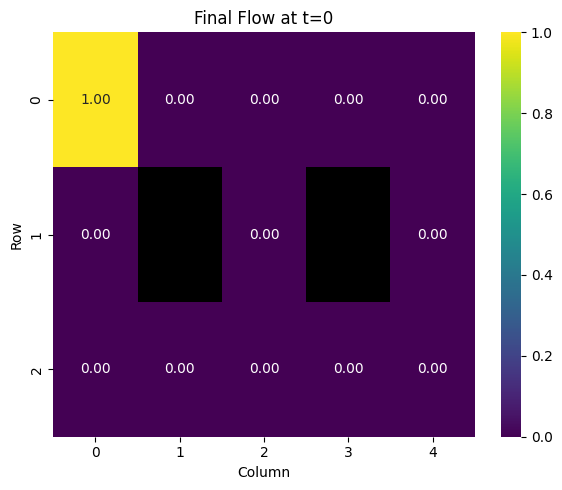

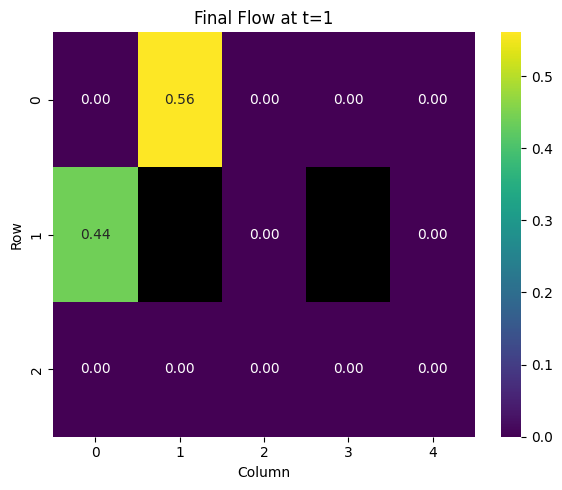

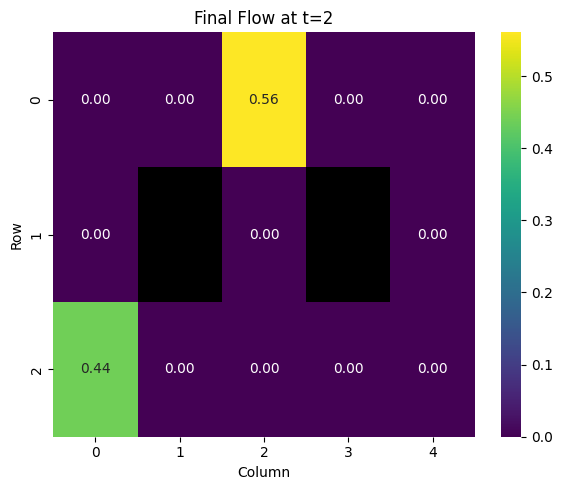

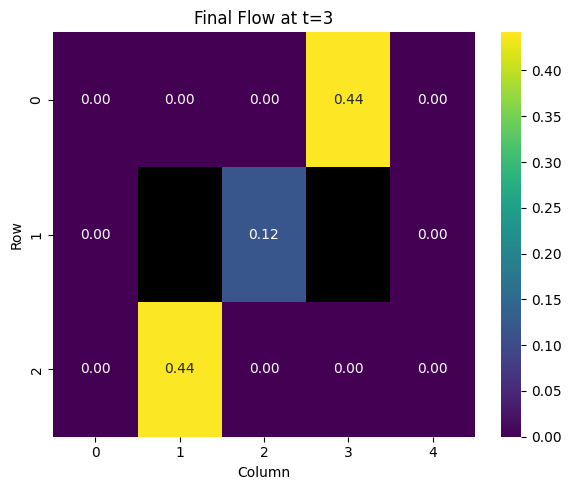

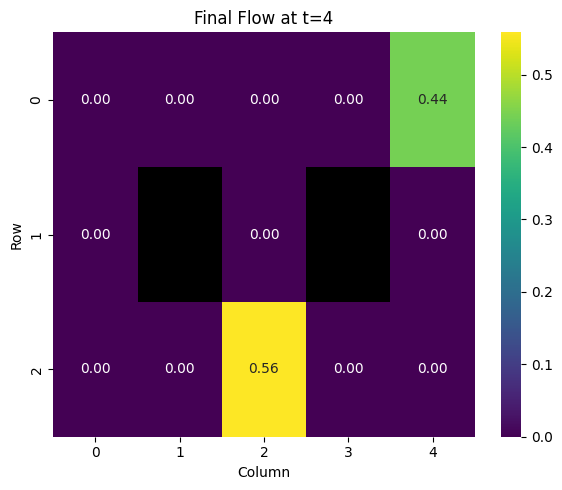

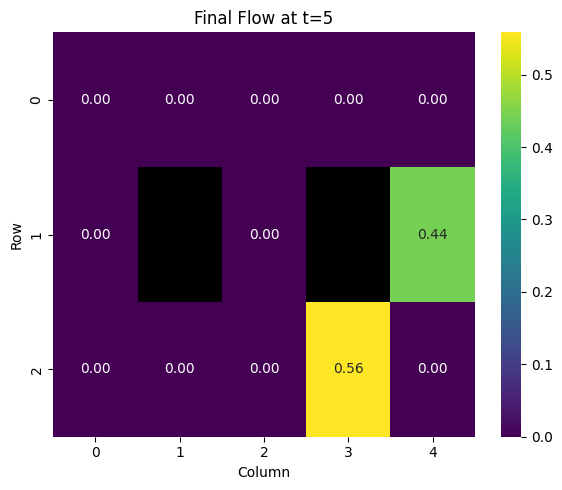

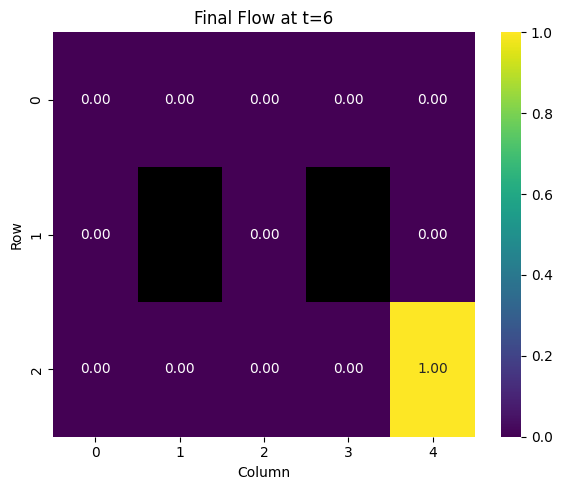

In [13]:
for i in range(final_flow.shape[0]):
    plot_heatmap(final_flow[i].cpu().detach().numpy(), mask=obstacles.cpu().detach().numpy(), title=f"Final Flow at t={i}", xlabel="Column", ylabel="Row")